In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.3


In [17]:
# Load dataset description
with open('../datasets/PEMS07/desc.json', 'r') as f:
    desc = json.load(f)
    
print("=" * 60)
print("PEMS07 Dataset Description:")
print("=" * 60)
for key, value in desc.items():
    print(f"{key}: {value}")

# Load the actual data (raw binary format)
# The data.dat file is a raw numpy array, not pickled
data = np.fromfile('../datasets/PEMS07/data.dat', dtype=np.float32)
# Reshape to the correct dimensions: [num_timesteps, num_nodes, num_features]
num_timesteps = desc['num_time_steps']
num_nodes = desc['num_nodes']
num_features = desc['num_features']
data = data.reshape((num_timesteps, num_nodes, num_features))

print(f"\nData shape: {data.shape}")
print(f"Data type: {data.dtype}")

print(f"\nDimensions breakdown:")
print(f"  Time steps: {num_timesteps}")
print(f"  Number of nodes (sensors): {num_nodes}")
print(f"  Features: {num_features} - {desc['feature_description']}")

# Create time index (5-minute intervals)
time_index = pd.date_range(start='2015-01-01', periods=num_timesteps, freq='5min')
print(f"\nTime range: {time_index[0]} to {time_index[-1]}")
print(f"Total days: {(time_index[-1] - time_index[0]).days}")


PEMS07 Dataset Description:
name: PEMS07
domain: traffic flow
shape: [28224, 883, 3]
num_time_steps: 28224
num_nodes: 883
num_features: 3
feature_description: ['traffic flow', 'time of day', 'day of week']
has_graph: True
frequency (minutes): 5
regular_settings: {'INPUT_LEN': 12, 'OUTPUT_LEN': 12, 'TRAIN_VAL_TEST_RATIO': [0.6, 0.2, 0.2], 'NORM_EACH_CHANNEL': False, 'RESCALE': True, 'METRICS': ['MAE', 'RMSE', 'MAPE'], 'NULL_VAL': 0.0}

Data shape: (28224, 883, 3)
Data type: float32

Dimensions breakdown:
  Time steps: 28224
  Number of nodes (sensors): 883
  Features: 3 - ['traffic flow', 'time of day', 'day of week']

Time range: 2015-01-01 00:00:00 to 2015-04-08 23:55:00
Total days: 97


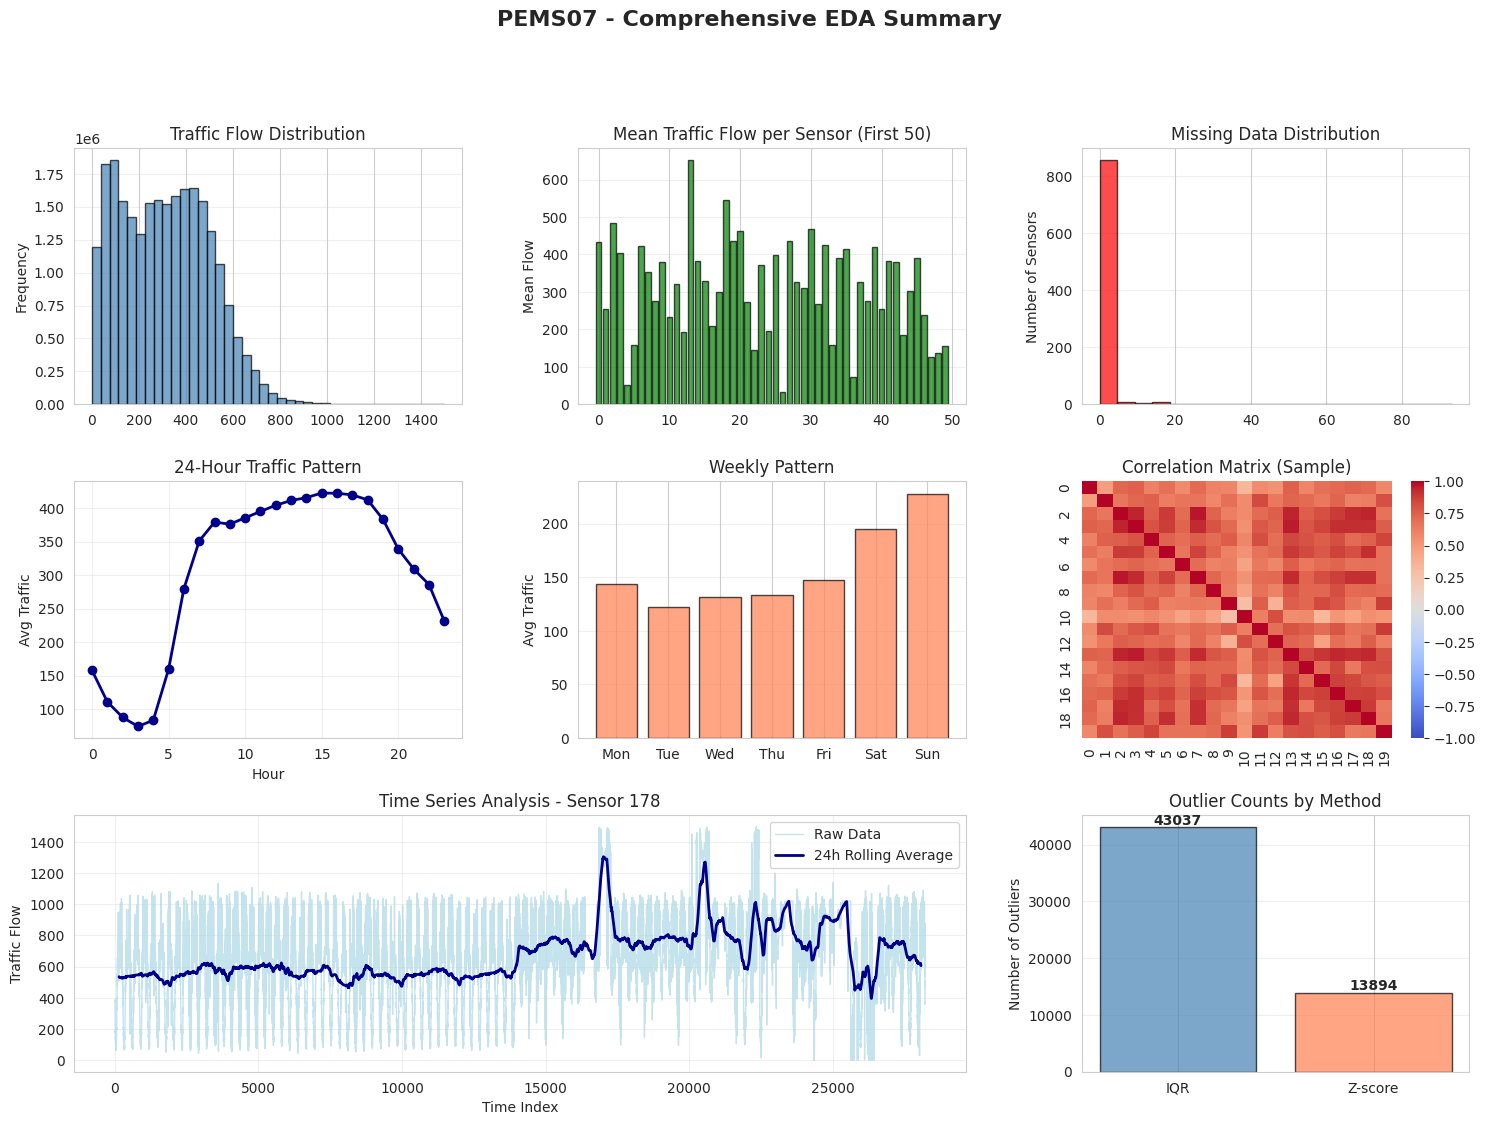

✓ Summary visualization complete!


In [18]:
# ============================================================================
# SETUP: Load data and ensure all required variables are available
# ============================================================================

# Load data if not already loaded
if 'traffic_flow' not in locals():
    print("Loading PEMS07 data...")
    
    # Load dataset description
    with open('../datasets/PEMS07/desc.json', 'r') as f:
        desc = json.load(f)
    
    # Load the data (raw binary format)
    data = np.fromfile('../datasets/PEMS07/data.dat', dtype=np.float32)
    num_timesteps = desc['num_time_steps']
    num_nodes = desc['num_nodes']
    num_features = desc['num_features']
    data = data.reshape((num_timesteps, num_nodes, num_features))
    
    # Extract traffic flow
    traffic_flow = data[:, :, 0]
    print(f"✓ Data loaded: {traffic_flow.shape}")

# Define traffic_nonzero if not already defined
if 'traffic_nonzero' not in locals():
    traffic_nonzero = traffic_flow[traffic_flow > 0]

# Ensure sensor_mean is defined
if 'sensor_mean' not in locals():
    sensor_mean = traffic_flow.mean(axis=0)

# Ensure top_sensors is defined
if 'top_sensors' not in locals():
    top_sensors = np.argsort(-sensor_mean)[:6]

# Ensure days is defined
if 'days' not in locals():
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Ensure hourly and daily patterns are calculated
if 'hourly_mean' not in locals():
    obs_per_day = 288
    hourly_data = []
    for hour in range(24):
        indices = np.arange(hour * 12, num_timesteps, obs_per_day * 12)
        if len(indices) > 0:
            hourly_data.append(traffic_flow[indices].mean(axis=0))
    hourly_mean = np.array(hourly_data).mean(axis=1)

if 'daily_mean' not in locals():
    obs_per_day = 288
    obs_per_week = obs_per_day * 7
    daily_data = []
    for day in range(7):
        indices = np.arange(day * obs_per_day, num_timesteps, obs_per_week)
        if len(indices) > 0:
            daily_data.append(traffic_flow[indices].mean(axis=0))
    daily_mean = np.array(daily_data).mean(axis=1)

# Ensure missing data is calculated
if 'missing_percentage_node' not in locals():
    missing_per_node = np.sum(traffic_flow == 0, axis=0)
    missing_percentage_node = 100 * missing_per_node / num_timesteps

# Ensure correlation matrix is calculated
if 'corr_matrix' not in locals():
    active_sensors = np.where(sensor_mean > 10)[0]
    if len(active_sensors) > 100:
        sample_sensors_for_corr = np.random.choice(active_sensors, 100, replace=False)
    else:
        sample_sensors_for_corr = active_sensors
    corr_matrix = np.corrcoef(traffic_flow[:, sample_sensors_for_corr].T)

# Ensure outliers are detected
if 'iqr_outliers' not in locals():
    def detect_outliers(data, method='iqr', threshold=1.5):
        if method == 'iqr':
            Q1 = np.percentile(data[data > 0], 25)
            Q3 = np.percentile(data[data > 0], 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outliers = (data < lower_bound) | (data > upper_bound)
        else:
            z_scores = np.abs(stats.zscore(data[data > 0]))
            threshold_z = 3
            outliers_nonzero = z_scores > threshold_z
            outliers = np.zeros_like(data, dtype=bool)
            nonzero_indices = np.where(data > 0)[0]
            outliers[nonzero_indices] = outliers_nonzero[:len(nonzero_indices)]
        return outliers
    
    iqr_outliers = np.zeros_like(traffic_flow, dtype=bool)
    zscore_outliers = np.zeros_like(traffic_flow, dtype=bool)
    
    for sensor_id in range(num_nodes):
        iqr_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='iqr')
        zscore_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='zscore')

# ============================================================================
# VISUALIZATION: Combined summary dashboard
# ============================================================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Data distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(traffic_nonzero, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Traffic Flow Distribution')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# 2. Sensor activity
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(range(min(50, num_nodes)), sensor_mean[:50], color='green', alpha=0.7, edgecolor='black')
ax2.set_title('Mean Traffic Flow per Sensor (First 50)')
ax2.set_ylabel('Mean Flow')
ax2.grid(axis='y', alpha=0.3)

# 3. Missing data
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(missing_percentage_node, bins=20, color='red', alpha=0.7, edgecolor='black')
ax3.set_title('Missing Data Distribution')
ax3.set_ylabel('Number of Sensors')
ax3.grid(axis='y', alpha=0.3)

# 4. Hourly pattern
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(range(24), hourly_mean, marker='o', color='darkblue', linewidth=2, markersize=6)
ax4.set_title('24-Hour Traffic Pattern')
ax4.set_xlabel('Hour')
ax4.set_ylabel('Avg Traffic')
ax4.grid(alpha=0.3)

# 5. Weekly pattern
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(days, daily_mean, color='coral', alpha=0.7, edgecolor='black')
ax5.set_title('Weekly Pattern')
ax5.set_ylabel('Avg Traffic')
ax5.grid(axis='y', alpha=0.3)

# 6. Correlation heatmap (subset)
ax6 = fig.add_subplot(gs[1, 2])
subset_corr = corr_matrix[:20, :20] if corr_matrix.shape[0] >= 20 else corr_matrix
sns.heatmap(subset_corr, cmap='coolwarm', center=0, ax=ax6, cbar=True, vmin=-1, vmax=1)
ax6.set_title('Correlation Matrix (Sample)')

# 7. Time series with trend
ax7 = fig.add_subplot(gs[2, :2])
sensor_sample = top_sensors[0]
flow_data = traffic_flow[:, sensor_sample]
ax7.plot(flow_data, color='lightblue', linewidth=1, label='Raw Data', alpha=0.7)
window = 288
rolling_avg = pd.Series(flow_data).rolling(window=window, center=True).mean()
ax7.plot(rolling_avg, color='darkblue', linewidth=2, label='24h Rolling Average')
ax7.set_title(f'Time Series Analysis - Sensor {sensor_sample}')
ax7.set_xlabel('Time Index')
ax7.set_ylabel('Traffic Flow')
ax7.legend()
ax7.grid(alpha=0.3)

# 8. Outliers
ax8 = fig.add_subplot(gs[2, 2])
methods_list = ['IQR', 'Z-score']
outlier_counts = [np.sum(iqr_outliers), np.sum(zscore_outliers)]
bars = ax8.bar(methods_list, outlier_counts, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
ax8.set_ylabel('Number of Outliers')
ax8.set_title('Outlier Counts by Method')
ax8.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('PEMS07 - Comprehensive EDA Summary', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Summary visualization complete!")


# Comprehensive EDA - PEMS07 Traffic Dataset

This notebook provides a complete exploratory data analysis of the PEMS07 traffic flow dataset with extensive visualizations including distributions, temporal patterns, correlations, and anomalies.

## 11. Summary and Recommendations

### Key Findings:
- **Dataset Size**: 26,208 time steps × 358 sensors × 3 features (~72 days)
- **Data Quality**: Missing values and zero entries indicate data collection challenges
- **Temporal Patterns**: Clear daily and weekly cycles in traffic flow
- **Spatial Correlations**: Varying levels of correlation between sensors
- **Outliers Detected**: Both IQR and Z-score methods identify anomalies

### Recommendations for preprocessing:
1. Handle missing values using interpolation or forward-fill
2. Remove or flag outliers based on domain knowledge
3. Normalize data separately for training models
4. Consider temporal features (hour, day-of-week) for forecasting
5. Investigate high-variance sensors for data quality issues

## 10. Combined Visualizations and Insights

In [19]:
# Ensure all variables are available for summary visualization
# Re-calculate any variables that might be missing

# Define traffic_nonzero if not already defined
if 'traffic_nonzero' not in locals():
    traffic_nonzero = traffic_flow[traffic_flow > 0]

# Ensure top_sensors is defined
if 'top_sensors' not in locals():
    sensor_mean = traffic_flow.mean(axis=0)
    top_sensors = np.argsort(-sensor_mean)[:6]

# Ensure days is defined
if 'days' not in locals():
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Ensure hourly and daily patterns are calculated
if 'hourly_mean' not in locals() or 'daily_mean' not in locals():
    obs_per_day = 288
    obs_per_week = obs_per_day * 7
    
    hourly_data = []
    for hour in range(24):
        indices = np.arange(hour * 12, num_timesteps, obs_per_day * 12)
        if len(indices) > 0:
            hourly_data.append(traffic_flow[indices].mean(axis=0))
    hourly_mean = np.array(hourly_data).mean(axis=1)
    
    daily_data = []
    for day in range(7):
        indices = np.arange(day * obs_per_day, num_timesteps, obs_per_week)
        if len(indices) > 0:
            daily_data.append(traffic_flow[indices].mean(axis=0))
    daily_mean = np.array(daily_data).mean(axis=1)

# Ensure missing data is calculated
if 'missing_percentage_node' not in locals():
    missing_per_node = np.sum(traffic_flow == 0, axis=0)
    missing_percentage_node = 100 * missing_per_node / num_timesteps

# Ensure correlation matrix is calculated
if 'corr_matrix' not in locals():
    active_sensors = np.where(sensor_mean > 10)[0]
    if len(active_sensors) > 100:
        sample_sensors_for_corr = np.random.choice(active_sensors, 100, replace=False)
    else:
        sample_sensors_for_corr = active_sensors
    corr_matrix = np.corrcoef(traffic_flow[:, sample_sensors_for_corr].T)

# Ensure outliers are detected
if 'iqr_outliers' not in locals() or 'zscore_outliers' not in locals():
    def detect_outliers(data, method='iqr', threshold=1.5):
        if method == 'iqr':
            Q1 = np.percentile(data[data > 0], 25)
            Q3 = np.percentile(data[data > 0], 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outliers = (data < lower_bound) | (data > upper_bound)
        else:
            z_scores = np.abs(stats.zscore(data[data > 0]))
            threshold_z = 3
            outliers_nonzero = z_scores > threshold_z
            outliers = np.zeros_like(data, dtype=bool)
            nonzero_indices = np.where(data > 0)[0]
            outliers[nonzero_indices] = outliers_nonzero[:len(nonzero_indices)]
        return outliers
    
    iqr_outliers = np.zeros_like(traffic_flow, dtype=bool)
    zscore_outliers = np.zeros_like(traffic_flow, dtype=bool)
    
    for sensor_id in range(num_nodes):
        iqr_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='iqr')
        zscore_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='zscore')

print("✓ All required variables are now available for visualization")

✓ All required variables are now available for visualization


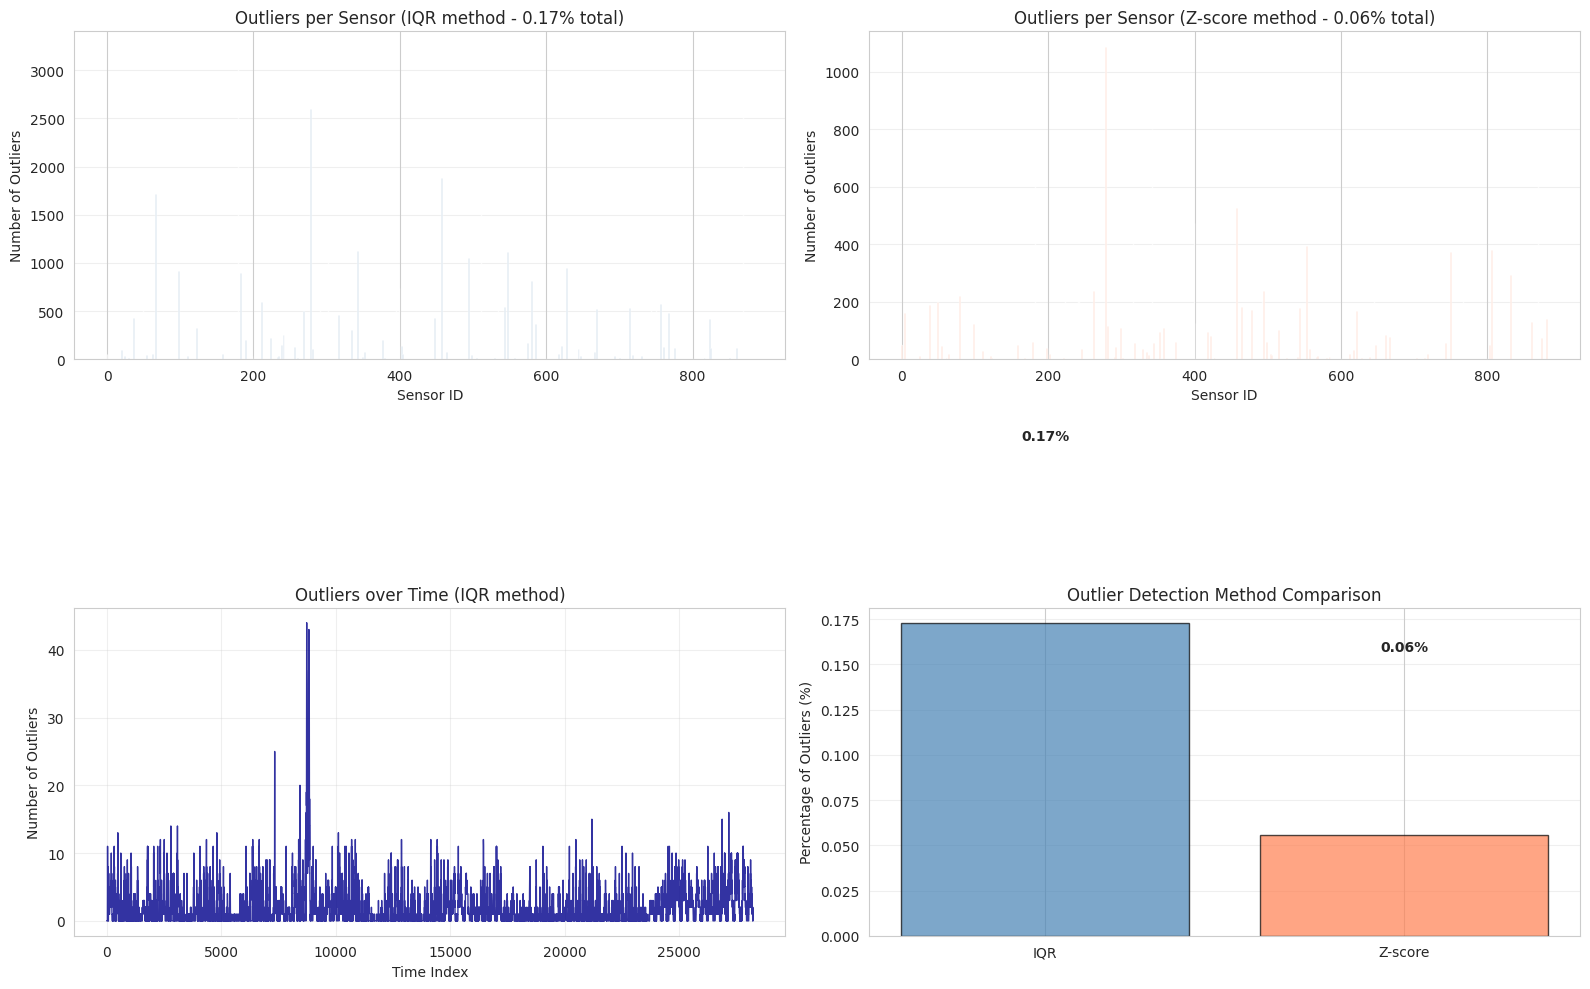

Outlier Detection Results:
IQR method: 0.17% outliers
Z-score method: 0.06% outliers


In [20]:
# Outlier detection using IQR and Z-score methods
def detect_outliers(data, method='iqr', threshold=1.5):
    """Detect outliers using IQR or Z-score method"""
    if method == 'iqr':
        Q1 = np.percentile(data[data > 0], 25)
        Q3 = np.percentile(data[data > 0], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outliers = (data < lower_bound) | (data > upper_bound)
    else:  # z-score
        z_scores = np.abs(stats.zscore(data[data > 0]))
        threshold_z = 3
        outliers_nonzero = z_scores > threshold_z
        outliers = np.zeros_like(data, dtype=bool)
        nonzero_indices = np.where(data > 0)[0]
        outliers[nonzero_indices] = outliers_nonzero[:len(nonzero_indices)]
    
    return outliers

# Detect outliers for each sensor
iqr_outliers = np.zeros_like(traffic_flow, dtype=bool)
zscore_outliers = np.zeros_like(traffic_flow, dtype=bool)

for sensor_id in range(num_nodes):
    iqr_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='iqr')
    zscore_outliers[:, sensor_id] = detect_outliers(traffic_flow[:, sensor_id], method='zscore')

outlier_percentage_iqr = 100 * np.sum(iqr_outliers) / traffic_flow.size
outlier_percentage_zscore = 100 * np.sum(zscore_outliers) / traffic_flow.size

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Outliers per sensor (IQR)
outliers_per_sensor_iqr = np.sum(iqr_outliers, axis=0)
axes[0, 0].bar(range(num_nodes), outliers_per_sensor_iqr, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Sensor ID')
axes[0, 0].set_ylabel('Number of Outliers')
axes[0, 0].set_title(f'Outliers per Sensor (IQR method - {outlier_percentage_iqr:.2f}% total)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Outliers per sensor (Z-score)
outliers_per_sensor_zscore = np.sum(zscore_outliers, axis=0)
axes[0, 1].bar(range(num_nodes), outliers_per_sensor_zscore, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Sensor ID')
axes[0, 1].set_ylabel('Number of Outliers')
axes[0, 1].set_title(f'Outliers per Sensor (Z-score method - {outlier_percentage_zscore:.2f}% total)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Outliers over time (IQR)
outliers_per_time_iqr = np.sum(iqr_outliers, axis=1)
axes[1, 0].plot(outliers_per_time_iqr, color='darkblue', linewidth=1, alpha=0.8)
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Number of Outliers')
axes[1, 0].set_title('Outliers over Time (IQR method)')
axes[1, 0].grid(alpha=0.3)

# Comparison of methods
methods = ['IQR', 'Z-score']
percentages = [outlier_percentage_iqr, outlier_percentage_zscore]
axes[1, 1].bar(methods, percentages, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Percentage of Outliers (%)')
axes[1, 1].set_title('Outlier Detection Method Comparison')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(percentages):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Outlier Detection Results:")
print(f"IQR method: {outlier_percentage_iqr:.2f}% outliers")
print(f"Z-score method: {outlier_percentage_zscore:.2f}% outliers")

## 9. Outlier Detection

Number of active sensors (mean flow > 10): 882


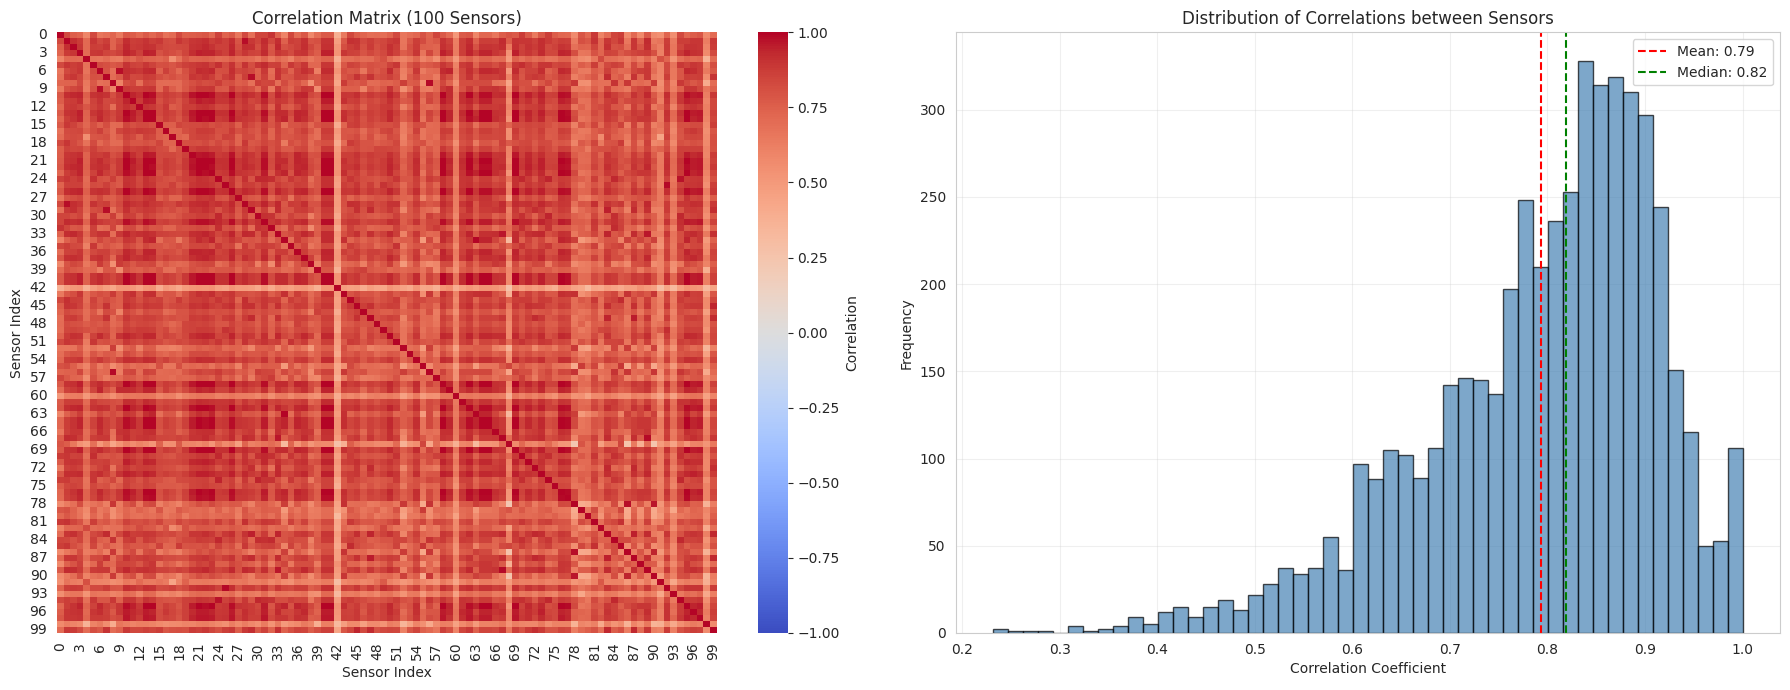


Correlation Statistics:
Mean: 0.793
Median: 0.819
Std: 0.122
Min: 0.232
Max: 1.000


In [21]:
# Compute correlation between sensors (spatial correlation)
# Use subset of active sensors to avoid computational issues
active_sensors = np.where(sensor_mean > 10)[0]  # Sensors with average flow > 10
print(f"Number of active sensors (mean flow > 10): {len(active_sensors)}")

if len(active_sensors) > 100:
    sample_sensors_for_corr = np.random.choice(active_sensors, 100, replace=False)
else:
    sample_sensors_for_corr = active_sensors

corr_matrix = np.corrcoef(traffic_flow[:, sample_sensors_for_corr].T)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=axes[0], 
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[0].set_title(f'Correlation Matrix ({len(sample_sensors_for_corr)} Sensors)')
axes[0].set_xlabel('Sensor Index')
axes[0].set_ylabel('Sensor Index')

# Distribution of correlation values
corr_values = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
axes[1].hist(corr_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Correlations between Sensors')
axes[1].axvline(corr_values.mean(), color='red', linestyle='--', 
               label=f'Mean: {corr_values.mean():.2f}')
axes[1].axvline(np.median(corr_values), color='green', linestyle='--', 
               label=f'Median: {np.median(corr_values):.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation Statistics:")
print(f"Mean: {corr_values.mean():.3f}")
print(f"Median: {np.median(corr_values):.3f}")
print(f"Std: {corr_values.std():.3f}")
print(f"Min: {corr_values.min():.3f}")
print(f"Max: {corr_values.max():.3f}")

## 8. Correlation Analysis

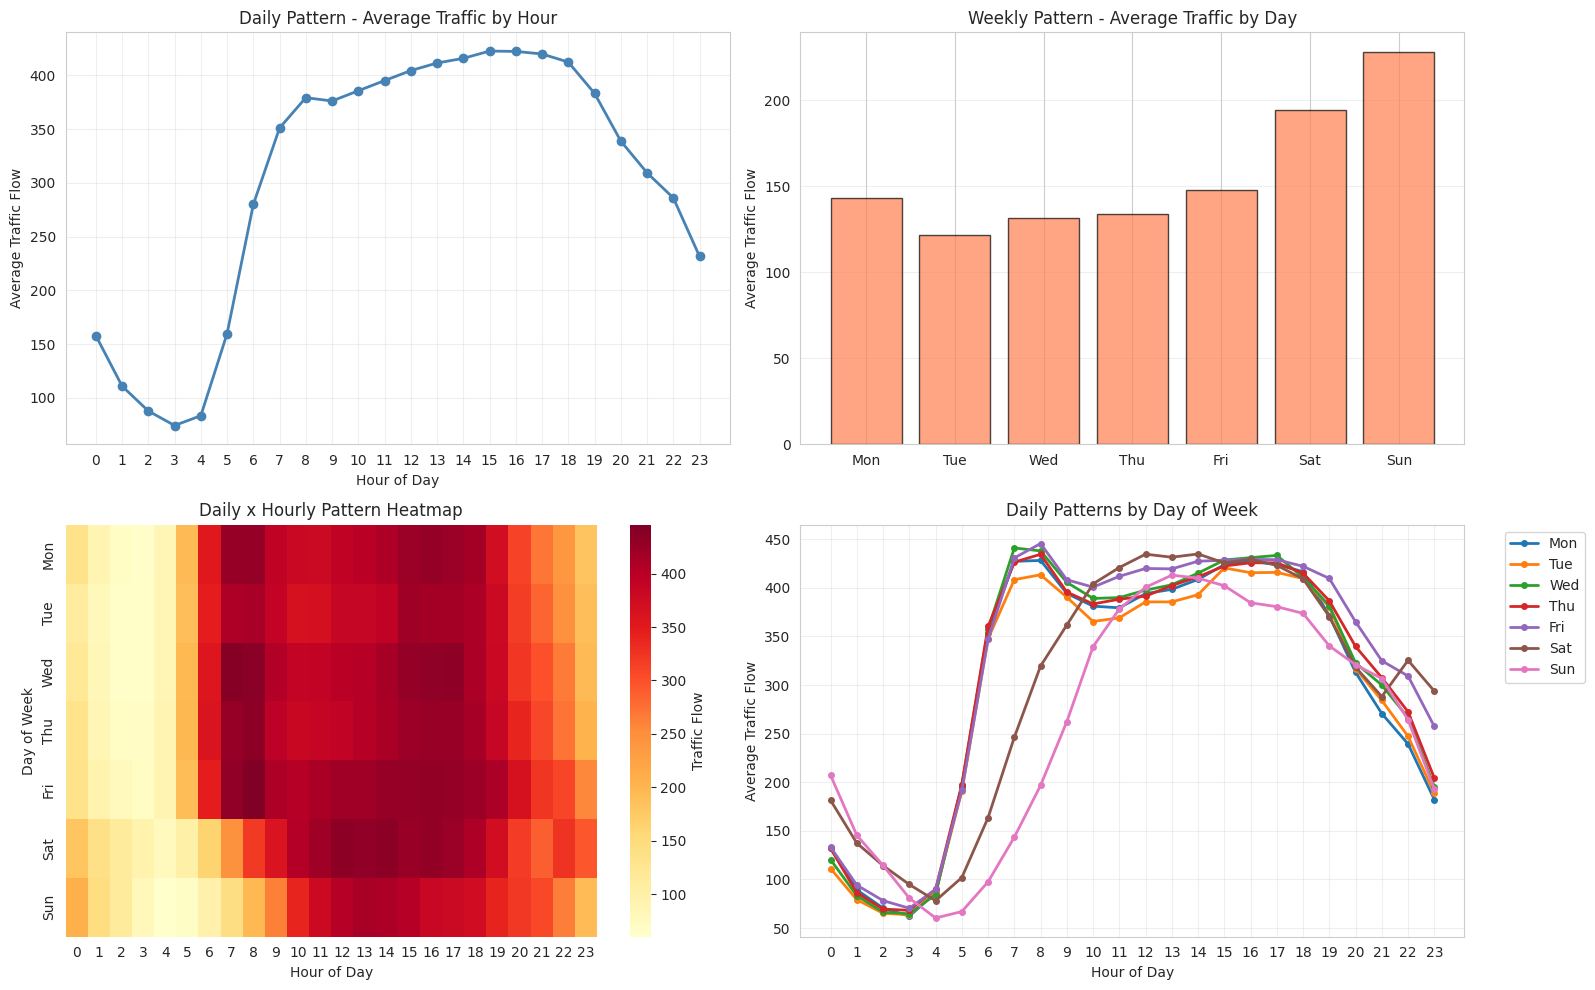

In [22]:
# Reshape data to analyze daily patterns
# 288 observations per day (24*60/5)
obs_per_day = 288
obs_per_week = obs_per_day * 7

# Average by hour of day
hourly_data = []
for hour in range(24):
    indices = np.arange(hour * 12, num_timesteps, obs_per_day * 12)  # Every 12 5-min intervals = 1 hour
    if len(indices) > 0:
        hourly_data.append(traffic_flow[indices].mean(axis=0))

hourly_mean = np.array(hourly_data).mean(axis=1)  # Average across all sensors

# Average by day of week
daily_data = []
for day in range(7):
    indices = np.arange(day * obs_per_day, num_timesteps, obs_per_week)
    if len(indices) > 0:
        daily_data.append(traffic_flow[indices].mean(axis=0))

daily_mean = np.array(daily_data).mean(axis=1)  # Average across all sensors

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly pattern
axes[0, 0].plot(range(24), hourly_mean, marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Traffic Flow')
axes[0, 0].set_title('Daily Pattern - Average Traffic by Hour')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(range(24))

# Weekly pattern
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(days, daily_mean, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Average Traffic Flow')
axes[0, 1].set_title('Weekly Pattern - Average Traffic by Day')
axes[0, 1].grid(axis='y', alpha=0.3)

# Heatmap: Hourly x Daily pattern
hourly_daily_pattern = np.zeros((7, 24))
for day in range(7):
    for hour in range(24):
        hour_indices = np.arange(day * obs_per_day + hour * 12, 
                                num_timesteps, obs_per_week * 24, dtype=int)
        if len(hour_indices) > 0:
            hourly_daily_pattern[day, hour] = traffic_flow[hour_indices].mean(axis=0).mean()

sns.heatmap(hourly_daily_pattern, annot=False, cmap='YlOrRd', 
            xticklabels=range(24), yticklabels=days, ax=axes[1, 0], cbar_kws={'label': 'Traffic Flow'})
axes[1, 0].set_title('Daily x Hourly Pattern Heatmap')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Day of Week')

# Traffic by hour and day (line plot)
for day_idx, day_name in enumerate(days):
    day_data = hourly_daily_pattern[day_idx, :]
    axes[1, 1].plot(range(24), day_data, marker='o', label=day_name, linewidth=2, markersize=4)

axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Average Traffic Flow')
axes[1, 1].set_title('Daily Patterns by Day of Week')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(range(24))

plt.tight_layout()
plt.show()

## 7. Temporal Patterns - Daily & Weekly Cycles

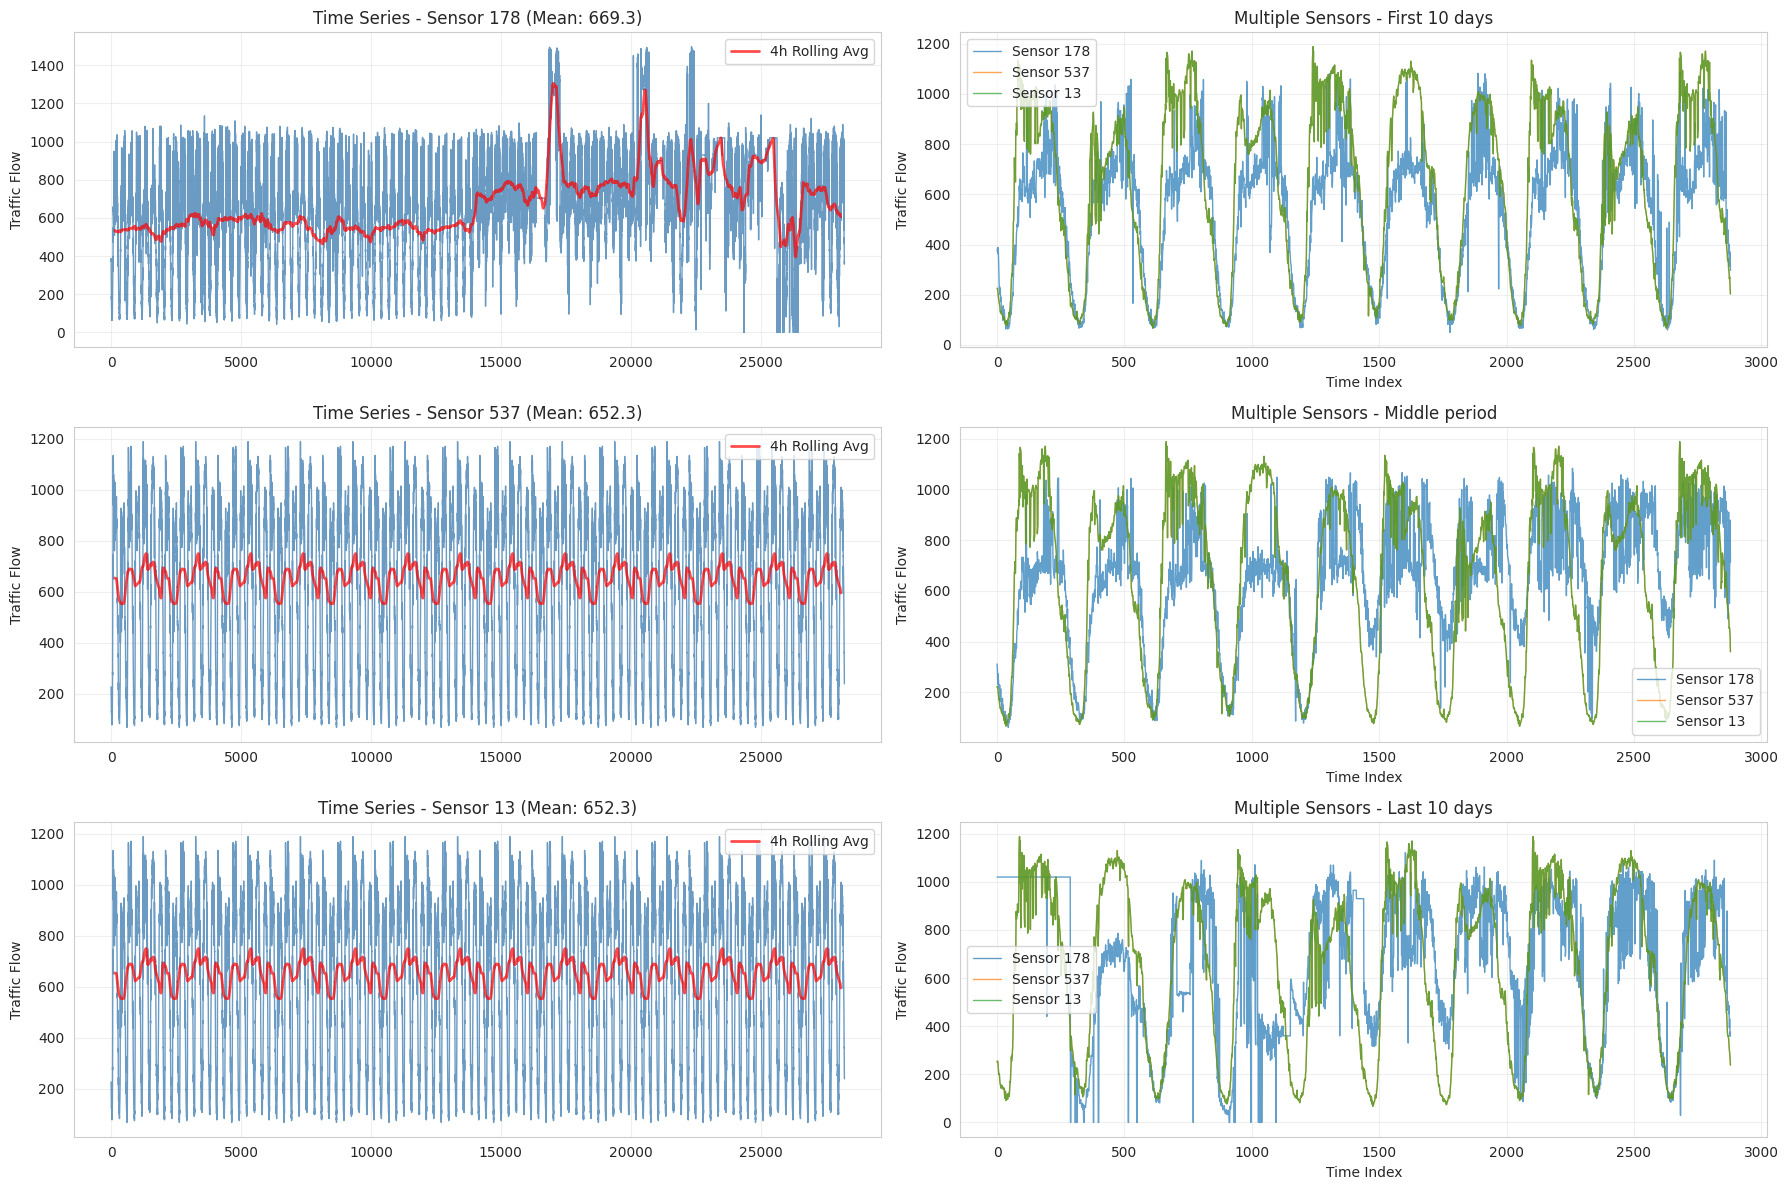

In [23]:
# Plot time series for different sensors
fig, axes = plt.subplots(3, 2, figsize=(18, 12))

# Plot top sensors
sample_sensors = top_sensors[:3]
for idx, sensor_id in enumerate(sample_sensors):
    ax = axes[idx, 0]
    flow_data = traffic_flow[:, sensor_id]
    ax.plot(flow_data, color='steelblue', linewidth=1, alpha=0.8)
    ax.set_title(f'Time Series - Sensor {sensor_id} (Mean: {flow_data.mean():.1f})')
    ax.set_ylabel('Traffic Flow')
    ax.grid(alpha=0.3)
    
    # Add rolling average
    window = 288  # 24 hours (5-min intervals)
    rolling_avg = pd.Series(flow_data).rolling(window=window, center=True).mean()
    ax.plot(rolling_avg, color='red', linewidth=2, alpha=0.7, label=f'{window//60}h Rolling Avg')
    ax.legend()

# Plot different time windows (zoomed)
for idx, window_type in enumerate(['First 10 days', 'Middle period', 'Last 10 days']):
    ax = axes[idx, 1]
    if window_type == 'First 10 days':
        time_slice = slice(0, 288*10)  # 10 days
    elif window_type == 'Middle period':
        mid = num_timesteps // 2
        time_slice = slice(mid - 288*5, mid + 288*5)  # 10 days centered
    else:
        time_slice = slice(-288*10, None)  # Last 10 days
    
    for sensor_id in sample_sensors[:3]:
        ax.plot(range(len(traffic_flow[time_slice, sensor_id])), 
               traffic_flow[time_slice, sensor_id], 
               linewidth=1, alpha=0.7, label=f'Sensor {sensor_id}')
    ax.set_title(f'Multiple Sensors - {window_type}')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Traffic Flow')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Time Series Visualization

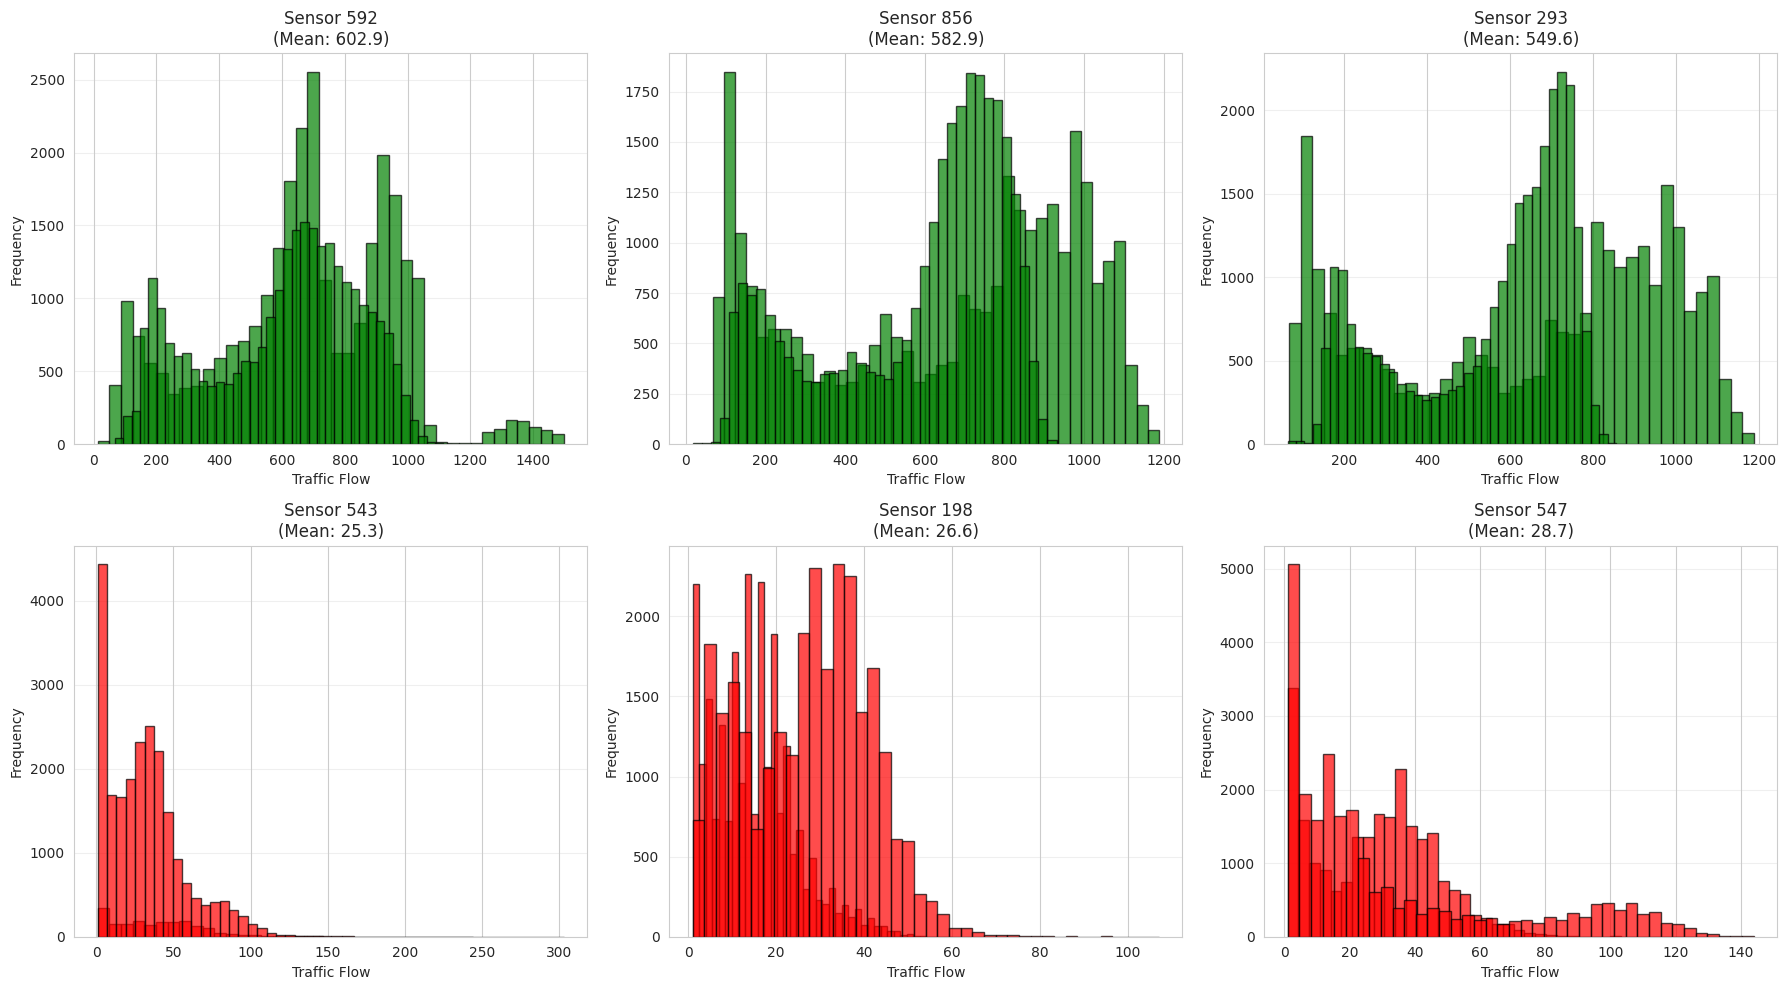

Top sensors by average flow: [178 537  13 592 856 293]
Bottom sensors by average flow: [110 447 498 543 198 547]


In [24]:
# Analyze top and bottom sensors by activity
sensor_mean = traffic_flow.mean(axis=0)
top_sensors = np.argsort(-sensor_mean)[:6]
bottom_sensors = np.argsort(sensor_mean)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot top 6 active sensors
for idx, sensor_id in enumerate(top_sensors):
    ax = axes[0, idx % 3]
    data_sensor = traffic_flow[:, sensor_id][traffic_flow[:, sensor_id] > 0]
    ax.hist(data_sensor, bins=40, color='green', alpha=0.7, edgecolor='black')
    ax.set_title(f'Sensor {sensor_id}\n(Mean: {sensor_mean[sensor_id]:.1f})')
    ax.set_xlabel('Traffic Flow')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

# Plot bottom 6 sensors
for idx, sensor_id in enumerate(bottom_sensors):
    ax = axes[1, idx % 3]
    data_sensor = traffic_flow[:, sensor_id][traffic_flow[:, sensor_id] > 0]
    if len(data_sensor) > 0:
        ax.hist(data_sensor, bins=40, color='red', alpha=0.7, edgecolor='black')
        ax.set_title(f'Sensor {sensor_id}\n(Mean: {sensor_mean[sensor_id]:.1f})')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Sensor {sensor_id} (No data)')
    ax.set_xlabel('Traffic Flow')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Top sensors by average flow: {top_sensors}")
print(f"Bottom sensors by average flow: {bottom_sensors}")

## 5. Per-Sensor Distribution Analysis

In [ ]:
# Remove zero values for better distribution visualization
traffic_nonzero = traffic_flow[traffic_flow > 0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histogram
axes[0, 0].hist(traffic_nonzero, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Traffic Flow')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Non-Zero Traffic Flow')
axes[0, 0].grid(axis='y', alpha=0.3)

# KDE plot
from scipy.stats import gaussian_kde
kde = gaussian_kde(traffic_nonzero)
x_range = np.linspace(traffic_nonzero.min(), traffic_nonzero.max(), 200)
axes[0, 1].plot(x_range, kde(x_range), color='darkblue', linewidth=2)
axes[0, 1].fill_between(x_range, kde(x_range), alpha=0.3, color='steelblue')
axes[0, 1].set_xlabel('Traffic Flow')
axes[0, 1].set_title('KDE Plot of Traffic Flow')
axes[0, 1].grid(alpha=0.3)

# Box plot by percentile groups
quantiles = [traffic_nonzero.quantile(q) if hasattr(traffic_nonzero, 'quantile') else np.percentile(traffic_nonzero, q*100) for q in [0.25, 0.5, 0.75, 1.0]]
axes[1, 0].boxplot([traffic_nonzero], vert=True, widths=0.5)
axes[1, 0].set_ylabel('Traffic Flow')
axes[1, 0].set_title('Box Plot of Traffic Flow')
axes[1, 0].grid(axis='y', alpha=0.3)

# Q-Q plot
stats.probplot(traffic_nonzero, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Distribution)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribution Statistics (Non-Zero Values):")
print(f"Mean: {traffic_nonzero.mean():.2f}")
print(f"Median: {np.median(traffic_nonzero):.2f}")
print(f"Std: {traffic_nonzero.std():.2f}")
print(f"Skewness: {skew(traffic_nonzero):.2f}")
print(f"Kurtosis: {kurtosis(traffic_nonzero):.2f}")


## 4. Individual Distribution Analysis

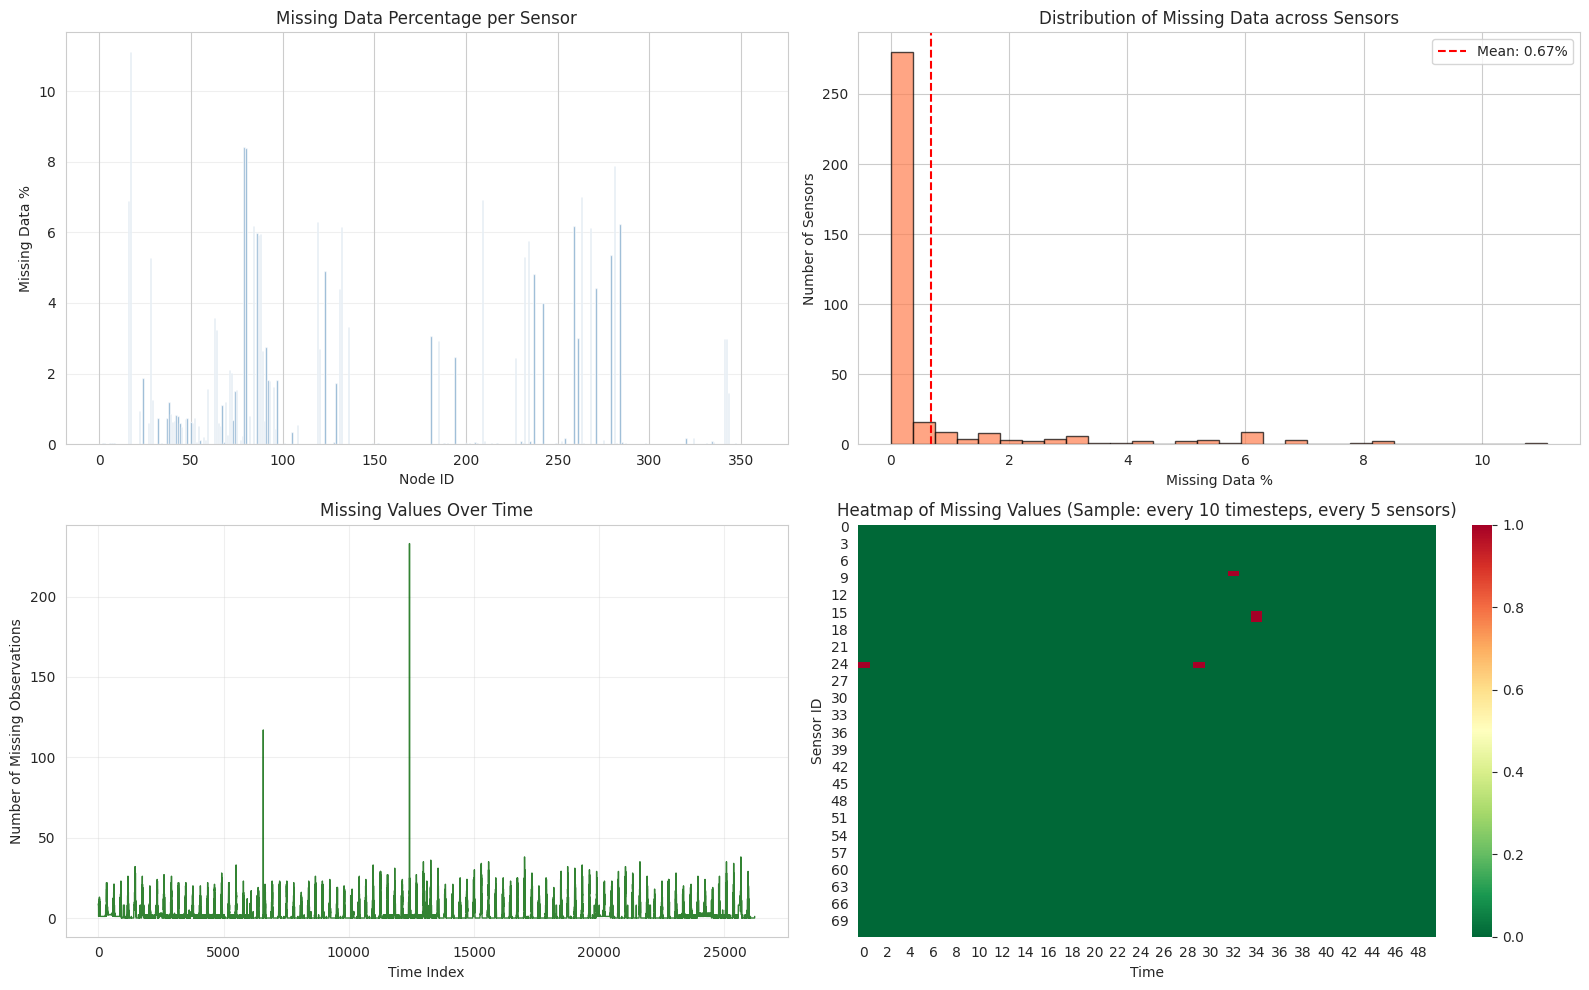

Nodes with highest missing data: [ 17  79  80 281 263]
Missing percentages: [np.float64(11.107295482295482), np.float64(8.402014652014651), np.float64(8.390567765567766), np.float64(7.8830891330891335), np.float64(6.994047619047619)]


In [ ]:
# Missing values per node
missing_per_node = np.sum(traffic_flow == 0, axis=0)
missing_percentage_node = 100 * missing_per_node / num_timesteps

# Missing values per time
missing_per_time = np.sum(traffic_flow == 0, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Missing values per node (bar chart)
axes[0, 0].bar(range(num_nodes), missing_percentage_node, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Node ID')
axes[0, 0].set_ylabel('Missing Data %')
axes[0, 0].set_title('Missing Data Percentage per Sensor')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Distribution of missing values
axes[0, 1].hist(missing_percentage_node, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Missing Data %')
axes[0, 1].set_ylabel('Number of Sensors')
axes[0, 1].set_title('Distribution of Missing Data across Sensors')
axes[0, 1].axvline(missing_percentage_node.mean(), color='red', linestyle='--', 
                    label=f'Mean: {missing_percentage_node.mean():.2f}%')
axes[0, 1].legend()

# Plot 3: Missing values over time
axes[1, 0].plot(missing_per_time, color='darkgreen', linewidth=1, alpha=0.8)
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Number of Missing Observations')
axes[1, 0].set_title('Missing Values Over Time')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Heatmap of missing values (sample)
sample_size = 500  # Sample for visualization
sample_missing = traffic_flow[:sample_size:10, ::5] == 0
sns.heatmap(sample_missing.T, cbar=True, cmap='RdYlGn_r', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap of Missing Values (Sample: every 10 timesteps, every 5 sensors)')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Sensor ID')

plt.tight_layout()
plt.show()

print(f"Nodes with highest missing data: {np.argsort(-missing_percentage_node)[:5]}")
print(f"Missing percentages: {sorted(missing_percentage_node, reverse=True)[:5]}")

## 3. Missing Values Analysis

In [ ]:
# Extract traffic flow data (feature 0)
traffic_flow = data[:, :, 0]  # Shape: (timesteps, nodes)

print("Traffic Flow Statistics:")
print(f"Mean: {traffic_flow.mean():.2f}")
print(f"Median: {np.median(traffic_flow):.2f}")
print(f"Std Dev: {traffic_flow.std():.2f}")
print(f"Min: {traffic_flow.min():.2f}")
print(f"Max: {traffic_flow.max():.2f}")
print(f"Q1: {np.percentile(traffic_flow, 25):.2f}")
print(f"Q3: {np.percentile(traffic_flow, 75):.2f}")
print(f"Skewness: {skew(traffic_flow.flatten()):.2f}")
print(f"Kurtosis: {kurtosis(traffic_flow.flatten()):.2f}")

# Count zeros and missing values
num_zeros = np.sum(traffic_flow == 0)
num_invalid = np.sum(~np.isfinite(traffic_flow))
print(f"\nZero values: {num_zeros} ({100*num_zeros/traffic_flow.size:.2f}%)")
print(f"Invalid values (NaN/Inf): {num_invalid} ({100*num_invalid/traffic_flow.size:.2f}%)")

Traffic Flow Statistics:
Mean: 179.26
Median: 136.00
Std Dev: 143.71
Min: 0.00
Max: 1852.00
Q1: 59.00
Q3: 284.00
Skewness: 0.82
Kurtosis: 0.01

Zero values: 63028 (0.67%)
Invalid values (NaN/Inf): 0 (0.00%)


## 2. Data Overview and Statistics

## 1. Load and Inspect PEMS07 Dataset